<a href="https://colab.research.google.com/github/RolandCoku/Computer-Vision/blob/main/Exercise_2_Image_Segmentation_Roland_Coku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2 - Image Segmentation

**Roland Çoku**  
Master's in Artificial Intelligence and Optimization  
Polytechnic University of Tirana

This notebook solves Exercise 2 for the Computer Vision course.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from skimage import data, img_as_float, io
from skimage.color import rgb2gray
from skimage.filters import gaussian, threshold_otsu
from skimage.transform import resize


plt.rcParams["figure.figsize"] = (8, 6)


## Task 1

Load an image and apply a thresholding method. Analyze and discuss the segmentation results.


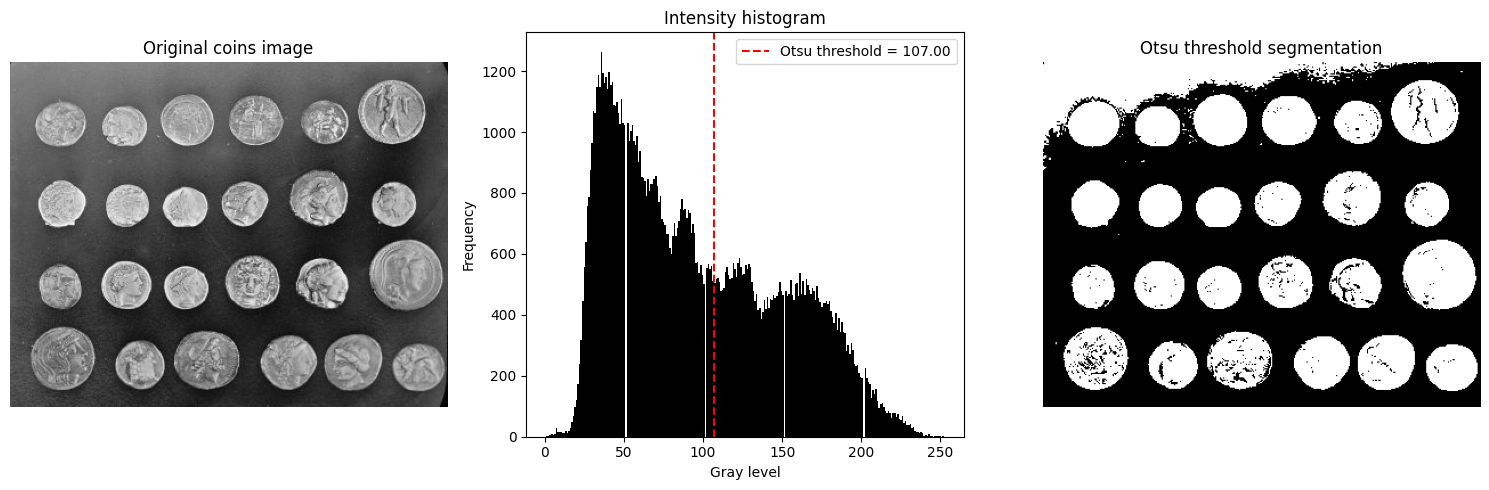

Otsu threshold: 107
Foreground pixel fraction: 0.38776299504950495


In [2]:
coins = data.coins()

threshold = threshold_otsu(coins)
coins_binary = coins > threshold

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(coins, cmap="gray")
axes[0].set_title("Original coins image")
axes[0].axis("off")

axes[1].hist(coins.ravel(), bins=256, color="black")
axes[1].axvline(threshold, color="red", linestyle="--", label=f"Otsu threshold = {threshold:.2f}")
axes[1].set_title("Intensity histogram")
axes[1].set_xlabel("Gray level")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].imshow(coins_binary, cmap="gray")
axes[2].set_title("Otsu threshold segmentation")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Otsu threshold:", threshold)
print("Foreground pixel fraction:", np.count_nonzero(coins_binary) / coins_binary.size)


Otsu thresholding separates the image into two classes by choosing a gray-level threshold from the histogram. It works reasonably well when foreground and background have different intensity distributions. In this image, it separates bright coin regions from darker background areas, but some shadows and highlights can still be misclassified because thresholding only uses pixel intensity.


## Task 2

Load an RGB image and apply an unsupervised segmentation method using K-Means clustering. Evaluate and comment on the outcome.


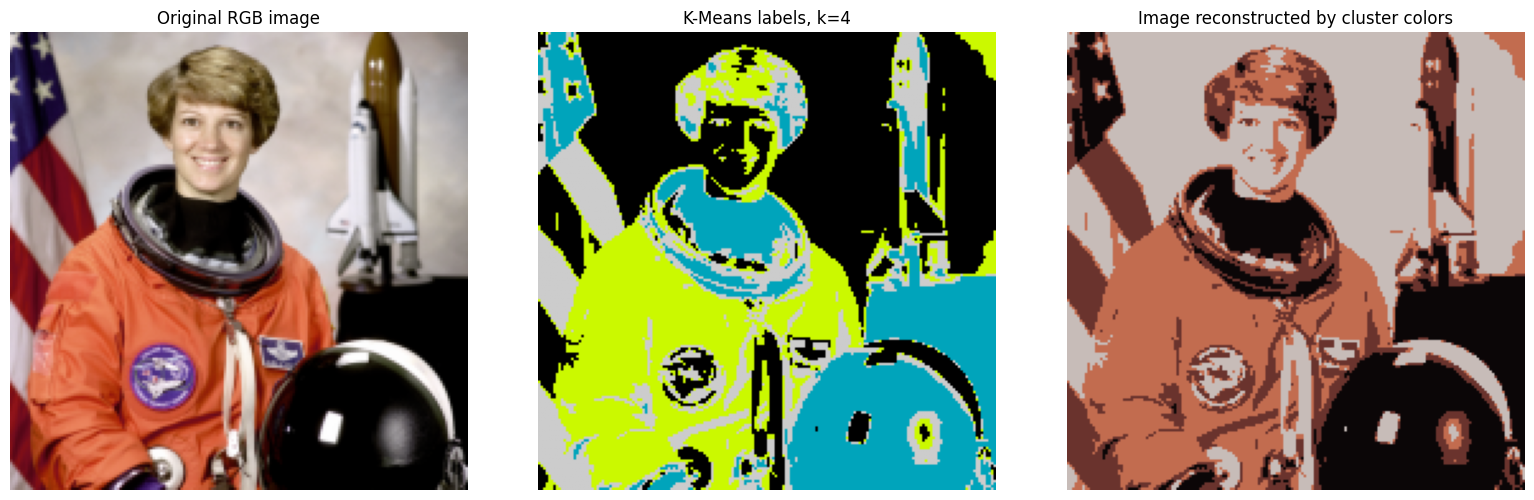

In [3]:
astronaut = data.astronaut()
astronaut_small = resize(astronaut, (180, 180), anti_aliasing=True)

pixels = astronaut_small.reshape(-1, 3)

kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(pixels)

kmeans_label_image = kmeans_labels.reshape(astronaut_small.shape[:2])
kmeans_segmented_image = kmeans.cluster_centers_[kmeans_labels].reshape(astronaut_small.shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(astronaut_small)
axes[0].set_title("Original RGB image")
axes[0].axis("off")

axes[1].imshow(kmeans_label_image, cmap="nipy_spectral")
axes[1].set_title("K-Means labels, k=4")
axes[1].axis("off")

axes[2].imshow(kmeans_segmented_image)
axes[2].set_title("Image reconstructed by cluster colors")
axes[2].axis("off")

plt.tight_layout()
plt.show()


K-Means groups pixels with similar RGB values without using any labels. The result separates regions with different colors, such as the background, skin/face area, and parts of the suit. However, K-Means does not understand object boundaries, so pixels from different objects can be assigned to the same cluster if their colors are similar. The number of clusters is also an important parameter.


## Task 3

Apply a supervised segmentation method using a classifier and annotated labels. The example below uses the vessel images and ground-truth masks from the course repository.


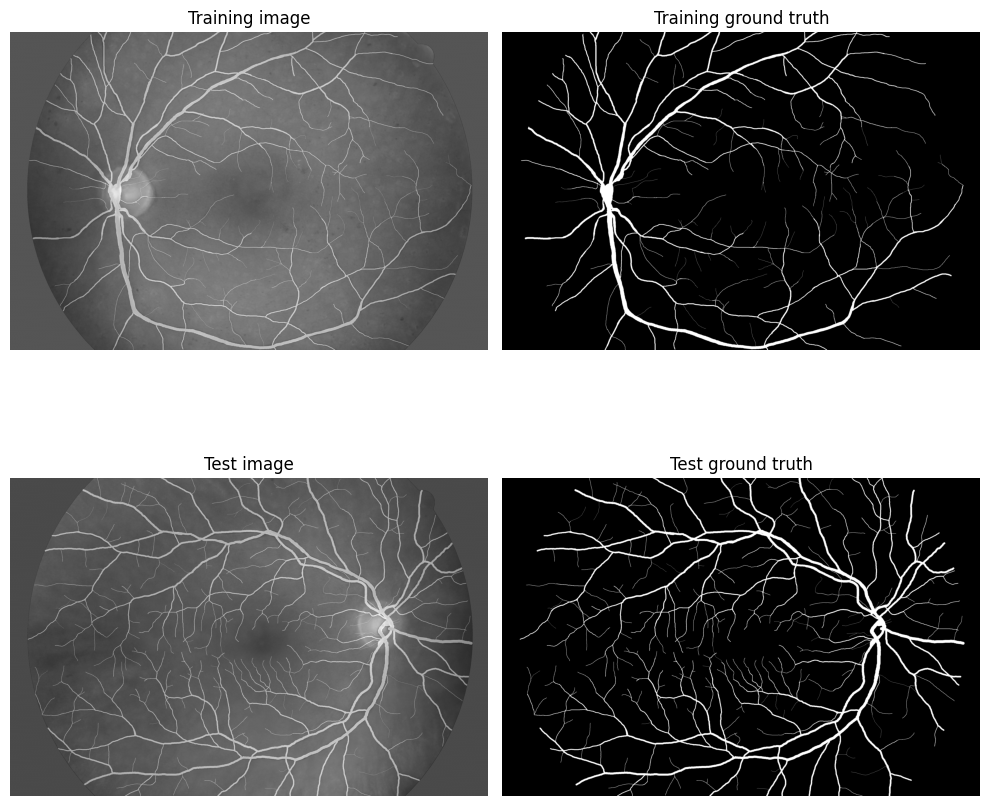

In [4]:
base_url = "https://raw.githubusercontent.com/xtianu/CV_Tirana_2026/main/M2_Image%20Segmentation/"

train_image_url = base_url + "vessels_train.jpg"
train_mask_url = base_url + "vessels_train_GT.tif"
test_image_url = base_url + "vessels_test.jpg"
test_mask_url = base_url + "vessels_test_GT.tif"


def read_gray_image(url):
    image = io.imread(url)
    if image.ndim == 3:
        image = rgb2gray(image)
    return img_as_float(image)


train_image = read_gray_image(train_image_url)
train_mask = read_gray_image(train_mask_url) > 0.5
test_image = read_gray_image(test_image_url)
test_mask = read_gray_image(test_mask_url) > 0.5

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(train_image, cmap="gray")
axes[0, 0].set_title("Training image")
axes[0, 0].axis("off")

axes[0, 1].imshow(train_mask, cmap="gray")
axes[0, 1].set_title("Training ground truth")
axes[0, 1].axis("off")

axes[1, 0].imshow(test_image, cmap="gray")
axes[1, 0].set_title("Test image")
axes[1, 0].axis("off")

axes[1, 1].imshow(test_mask, cmap="gray")
axes[1, 1].set_title("Test ground truth")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


In [5]:
def pixel_features(gray_image):
    rows, cols = gray_image.shape
    rr, cc = np.indices(gray_image.shape)

    features = np.column_stack(
        [
            gray_image.ravel(),
            gaussian(gray_image, sigma=1).ravel(),
            gaussian(gray_image, sigma=2).ravel(),
            (rr / rows).ravel(),
            (cc / cols).ravel(),
        ]
    )
    return features


X_train_all = pixel_features(train_image)
y_train_all = train_mask.ravel().astype(int)
X_test_all = pixel_features(test_image)
y_test_all = test_mask.ravel().astype(int)

rng = np.random.default_rng(0)
positive_indices = np.flatnonzero(y_train_all == 1)
negative_indices = np.flatnonzero(y_train_all == 0)

sample_per_class = min(len(positive_indices), len(negative_indices), 10000)
balanced_indices = np.concatenate(
    [
        rng.choice(positive_indices, sample_per_class, replace=False),
        rng.choice(negative_indices, sample_per_class, replace=False),
    ]
)

X_balanced = X_train_all[balanced_indices]
y_balanced = y_train_all[balanced_indices]

X_train, X_validation, y_train, y_validation = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.25,
    random_state=0,
    stratify=y_balanced,
)

classifier = RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=-1)
classifier.fit(X_train, y_train)

validation_prediction = classifier.predict(X_validation)
validation_accuracy = accuracy_score(y_validation, validation_prediction)

test_prediction = classifier.predict(X_test_all)
test_prediction_image = test_prediction.reshape(test_image.shape)

intersection = np.logical_and(test_prediction_image, test_mask).sum()
dice_score = (2 * intersection) / (test_prediction_image.sum() + test_mask.sum())

print("Validation accuracy:", validation_accuracy)
print("Test accuracy:", accuracy_score(y_test_all, test_prediction))
print("Dice score:", dice_score)
print("Confusion matrix:")
print(confusion_matrix(y_test_all, test_prediction))


Validation accuracy: 0.9994
Test accuracy: 0.9964283724666917
Dice score: 0.9739070363980553
Confusion matrix:
[[7610518   27194]
 [   2041  545591]]


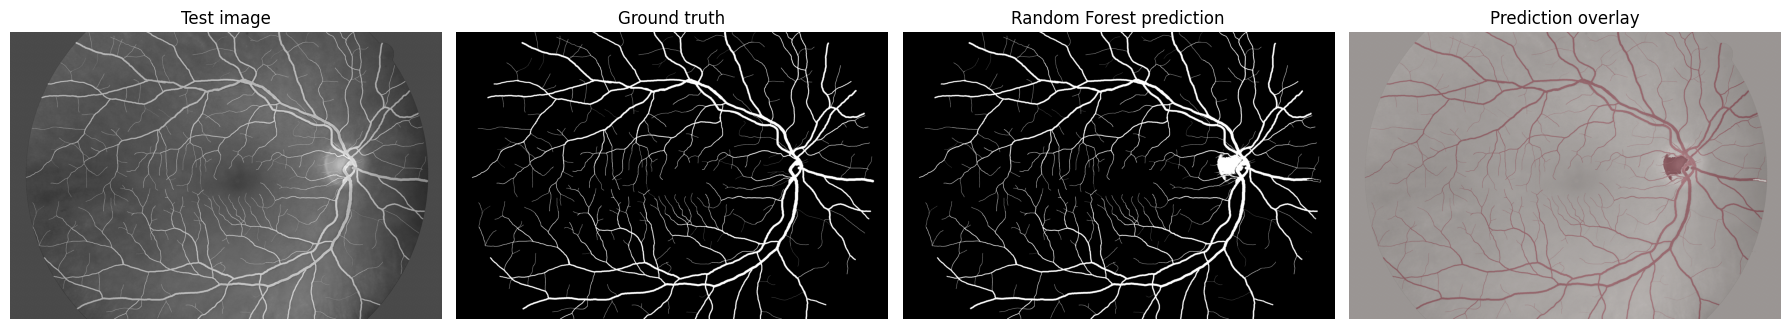

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Test image")
axes[0].axis("off")

axes[1].imshow(test_mask, cmap="gray")
axes[1].set_title("Ground truth")
axes[1].axis("off")

axes[2].imshow(test_prediction_image, cmap="gray")
axes[2].set_title("Random Forest prediction")
axes[2].axis("off")

axes[3].imshow(test_image, cmap="gray")
axes[3].imshow(test_prediction_image, cmap="Reds", alpha=0.45)
axes[3].set_title("Prediction overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()


The supervised method uses labeled pixels from a training image to learn how vessel and background pixels differ. The classifier can use several pixel features, not only the original intensity. This usually gives more targeted segmentation than unsupervised clustering, but it depends on the quality and quantity of the labeled training data. If the test image is very different from the training image, performance can decrease.


## Task 4

Explain the main differences between supervised and unsupervised segmentation approaches. Discuss their advantages and disadvantages, and illustrate the explanation with an example.


**Unsupervised segmentation** does not require ground-truth labels. It groups pixels according to similarity in features such as gray level, RGB color, or texture. Examples include thresholding, K-Means, and Gaussian Mixture Models. The main advantage is that it is easy to apply when no annotated data exists. The main limitation is that the clusters are not necessarily meaningful objects, and the result depends strongly on parameters such as the number of clusters.

**Supervised segmentation** requires labeled examples. A classifier is trained using features extracted from pixels or regions, and then it predicts the class of unseen pixels. Examples include Random Forest, LDA, Naive Bayes, SVMs, and neural networks. The main advantage is that it can learn the specific appearance of the target object. The main limitation is that it needs annotated data, and creating reliable labels can be expensive.

For example, K-Means can segment an RGB image into groups of similar colors without knowing what the objects are. A supervised vessel segmentation classifier, on the other hand, learns from annotated vessel masks and predicts whether each pixel is vessel or background.
